C:\Users\natej\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


              precision    recall  f1-score   support

 not-Aquacel       0.27      1.00      0.43         3
     Aquacel       0.00      0.00      0.00         8

   micro avg       0.27      0.27      0.27        11
   macro avg       0.14      0.50      0.21        11
weighted avg       0.07      0.27      0.12        11
 samples avg       0.27      0.27      0.27        11

Accuracy: 27.27272727272727 %


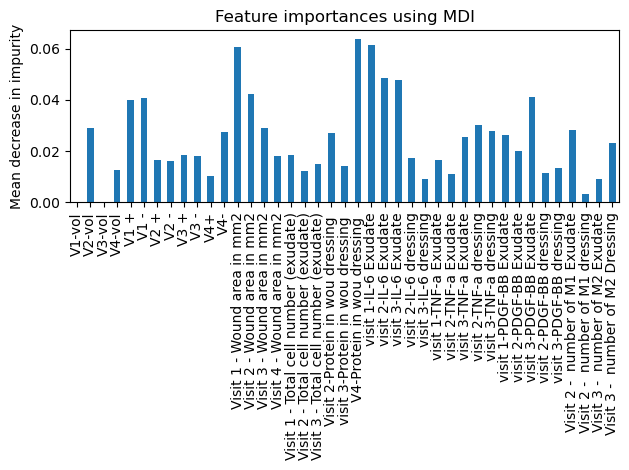

[[0.7875276  0.207158  ]
 [0.5734886  0.42536923]
 [0.6338356  0.36990583]
 [0.6718265  0.33767   ]
 [0.8341316  0.16546892]
 [0.67897505 0.32230267]
 [0.70171875 0.29714358]
 [0.6862247  0.31237432]
 [0.8275553  0.17634572]
 [0.5085072  0.4888024 ]
 [0.87681717 0.12213629]]
[[ True False]
 [ True False]
 [ True False]
 [ True False]
 [ True False]
 [ True False]
 [ True False]
 [ True False]
 [ True False]
 [ True False]
 [ True False]]


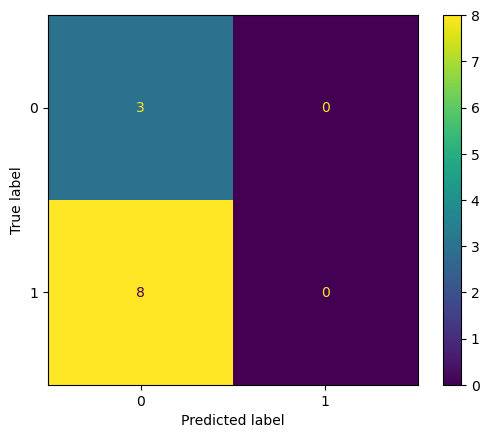

<Figure size 40000x12000 with 0 Axes>

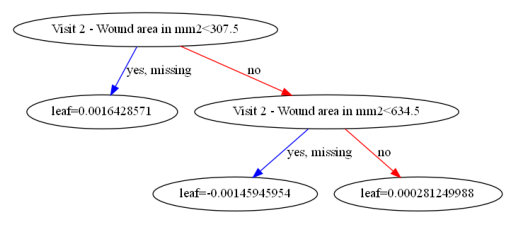

              precision    recall  f1-score   support

 not-Aquacel       1.00      1.00      1.00        10
     Aquacel       1.00      1.00      1.00         7

   micro avg       1.00      1.00      1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17
 samples avg       1.00      1.00      1.00        17

--------------------------------------------------------------------------------------------------


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from dtreeviz import model
from sklearn.ensemble import VotingClassifier

W_tree=2

Treatment=pd.read_csv("../dissertation/Aquacel test.csv")
Treatment_test=pd.read_csv("../dissertation/Aquacel test test.csv")


X_train=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]

X_test=Treatment_test.iloc[:,1:]
df_y_test=Treatment_test.iloc[:,0]


y_train = to_categorical(df_y)
y_test = to_categorical(df_y_test)




clf=XGBClassifier(booster="dart",
                  normalize_type="tree",
                  tree_method="exact",
                  objective="reg:logistic",
                  eta=0.09,
                  max_depth=None,
                  subsample=0.9,
                  colsample_bytree=0.5,
                  colsample_bylevel=0.6,
                  colsample_bynode=0.6,
                  reg_lambda=0.6,
                  reg_alpha=0.7,
                  rate_drop=1,
                  skip_drop=0.5,
                  one_drop=1,
                 #min_child_weight=0,
                  sample_type="weighted",
                  num_parallel_tree=60
                  
    )




clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 


print(classification_report(y_test,y_pred,output_dict=False,target_names=["not-Aquacel","Aquacel"]))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

names=clf.get_booster().feature_names

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

f = open("out.txt", "w")
var=clf.get_booster().get_dump()
for line in var:
    f.write(f"{line}\n")
f.close()

print(clf.predict_proba(X_test))
print(y_pred)

cm = confusion_matrix(y_test.argmax(axis=1), y_pred.argmax(axis=1))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()



y_pred = clf.predict(X_train)
y_pred = (y_pred > 0.5) 
print(classification_report(y_train,y_pred,output_dict=False,target_names=["not-Aquacel","Aquacel"]))




print("--------------------------------------------------------------------------------------------------")

target = 'key'
class_names=["not-Aquacel ","Aquacel"]


#Which_data=df_y_test
Which_data=df_y

from supertree import SuperTree
st = SuperTree(
    clf, 
    X_test, 
    Which_data, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree(which_tree=W_tree)

